In [5]:
#Part a) EDA
# i)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data_path="pulsar_data_train.csv"
df = pd.read_csv(data_path)

print (f"Shape: {df.shape}")
print (f"Data types:\n{df.dtypes}")
print ("\n ================= Describe =================\n")
print(df.describe())

pulsar_percent = (df['target_class'].sum() / len(df)) * 100  #since target is 0,1 we can simply sum all rows
print (f"\n\nPercentage of pulsars: {pulsar_percent:.2f}%")



Shape: (12528, 9)
Data types:
 Mean of the integrated profile                  float64
 Standard deviation of the integrated profile    float64
 Excess kurtosis of the integrated profile       float64
 Skewness of the integrated profile              float64
 Mean of the DM-SNR curve                        float64
 Standard deviation of the DM-SNR curve          float64
 Excess kurtosis of the DM-SNR curve             float64
 Skewness of the DM-SNR curve                    float64
target_class                                     float64
dtype: object

 ================= Describe =================

        Mean of the integrated profile  \
count                     12528.000000   
mean                        111.041841   
std                          25.672828   
min                           5.812500   
25%                         100.871094   
50%                         115.183594   
75%                         127.109375   
max                         189.734375   

        Standard

Accuracy alone can be misleading because the percentage of pulsars is very low. A simple model guessing every datapoint is 0 will be correct 90.8% of times. 

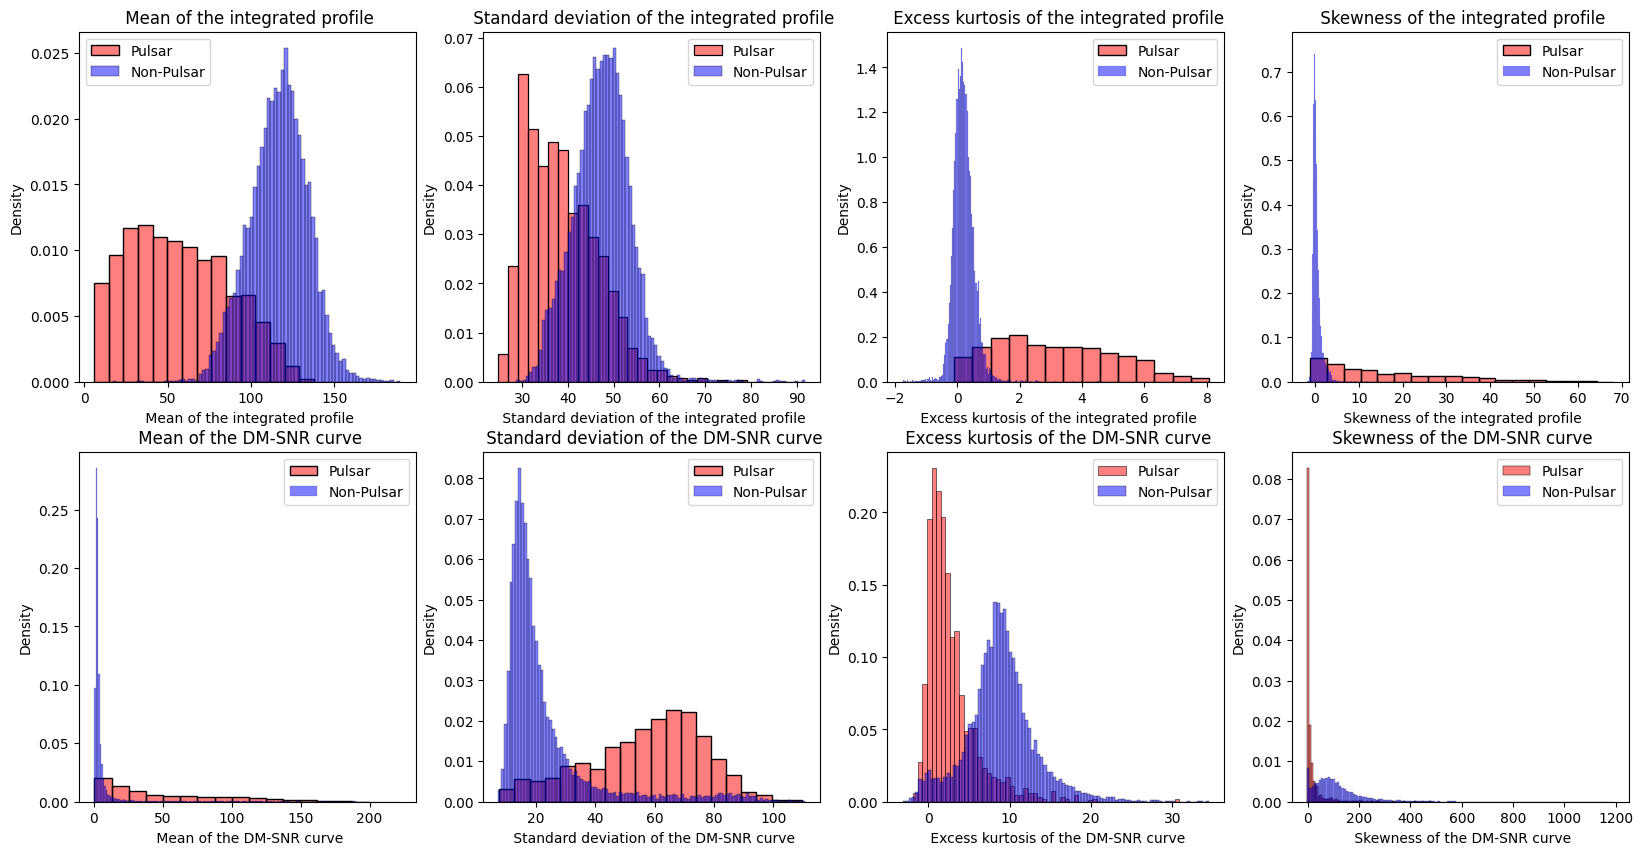

In [13]:
# ii)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
features = df.columns[:-1].tolist()
target = df.columns[-1] 

for i, col in enumerate(features):
    # Filter using the target name we just grabbed
    pulsars = df[df[target] == 1][col]
    non_pulsars = df[df[target] == 0][col]
    
    sns.histplot(pulsars, color='red', label='Pulsar', 
                 alpha=0.5, ax=axes[i], kde=False, stat="density")
    sns.histplot(non_pulsars, color='blue', label='Non-Pulsar', 
                 alpha=0.5, ax=axes[i], kde=False, stat="density")
    
    axes[i].set_title(col)
    axes[i].legend()

The most important features look like Excess Kurtosis of the DM-SNR curve, Standard deviation of DM-SNR curve, and skewness of the integrated profile

In [23]:
#iii)
import numpy as np
from sklearn.model_selection import train_test_split

df_clean = df.dropna()
X = df_clean.iloc[:, :-1].values
y = df_clean.iloc[:, -1].values

y = np.where(y == 0, -1, 1) 

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

train_mean = np.mean(X_train, axis=0)
train_std = np.std(X_train, axis=0)

#If any standard deviation is 0, replace it with 1 to prevent division by zero
train_std = np.where(train_std == 0, 1.0, train_std)

X_train_scaled = (X_train - train_mean) / train_std
X_val_scaled = (X_val - train_mean) / train_std
X_test_scaled = (X_test - train_mean) / train_std

X_train_final = np.c_[X_train_scaled, np.ones(X_train_scaled.shape[0])]
X_val_final = np.c_[X_val_scaled, np.ones(X_val_scaled.shape[0])]
X_test_final = np.c_[X_test_scaled, np.ones(X_test_scaled.shape[0])]

y_train = y_train.flatten()
y_val = y_val.flatten()
y_test = y_test.flatten()

print(f"X_train shape: {X_train_final.shape} (Includes 8 features + 1 bias column)")
print(f"y_train shape: {y_train.shape}")
print(f"y_train unique labels: {np.unique(y_train)}")
print("2. X_train NaNs:", np.isnan(X_train_final).any())

X_train shape: (5563, 9) (Includes 8 features + 1 bias column)
y_train shape: (5563,)
y_train unique labels: [-1  1]
2. X_train NaNs: False


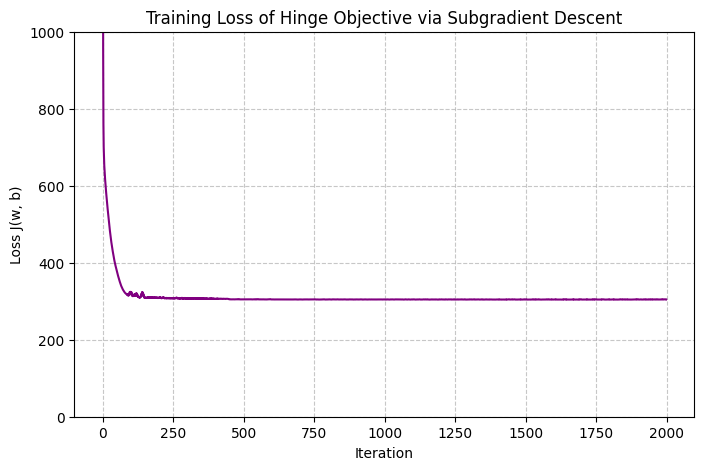

In [28]:
# b)
# i)
def compute_gradient_hinge(X, y, w, lambda_reg):

    margins = y * np.dot(X, w)
    
    active_multipliers = -y * (margins < 1)
    grad_loss = np.dot(X.T, active_multipliers)
    
    w_reg = w.copy()
    w_reg[-1] = 0  #don't regularize the bias term
    
    grad_reg = lambda_reg * w_reg
    
    grad_total = grad_loss + grad_reg
    
    return grad_total

def compute_J_hinge(X, y, w, lambda_reg):
    # 1. Hinge loss: sum(max(0, 1 - m_n))
    margins = y * np.dot(X, w)
    hinge_loss = np.sum(np.maximum(0, 1 - margins))
    
    # 2. Regularization: (lambda / 2) * ||w||^2
    w_no_bias = w[:-1]
    reg_loss = (lambda_reg / 2) * np.sum(w_no_bias**2)
    
    return hinge_loss + reg_loss

lambda_reg = 1e-3
eta = 1e-3
iterations = 2000


w = np.zeros(X_train_final.shape[1])
loss_history = []

# Training Loop
for i in range(iterations):
    # Calculate and store current loss
    current_loss = compute_J_hinge(X_train_final, y_train, w, lambda_reg)
    loss_history.append(current_loss)
    
    # Compute gradient
    grad = compute_gradient_hinge(X_train_final, y_train, w, lambda_reg)
    
    # Update weights
    w = w - eta * grad

# Plotting the loss
plt.figure(figsize=(8, 5))
plt.plot(range(iterations), loss_history, color='purple', linewidth=1.5)
plt.title('Training Loss of Hinge Objective via Subgradient Descent')
plt.ylim(0, 1000)
plt.xlabel('Iteration')
plt.ylabel('Loss J(w, b)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

The loss does not decrease monotonically because the loss function is not differentiable at 0, which causes the gradient to change abruptly. 

In [30]:
# iii)
def compute_accuracy(x,y,w):
    y_train_pred = np.sign(np.dot(X_train_final, w))
    y_val_pred = np.sign(np.dot(X_val_final, w))

    # Edge cases
    y_train_pred[y_train_pred == 0] = -1 
    y_val_pred[y_val_pred == 0] = -1

    train_acc = np.mean(y_train_pred == y_train)
    val_acc = np.mean(y_val_pred == y_val)

    return train_acc, val_acc


train_acc, val_acc = compute_accuracy(X_train_final, y_train, w)
print(f"Training Accuracy:   {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}\n")

# 2. Margin Analysis
# Recalculate margins for the final weights
margins = y_train * np.dot(X_train_final, w)

# Create boolean masks for safe (m >= 1) and active (m < 1) points
zero_subgradient_mask = margins >= 1
active_mask = margins < 1

print("--- Safe Points (m >= 1, Zero Gradient) ---")
print(f"Total safe points:     {np.sum(zero_subgradient_mask)}")
print(f"Safe Pulsars (+1):     {np.sum(zero_subgradient_mask & (y_train == 1))}")
print(f"Safe Non-Pulsars (-1): {np.sum(zero_subgradient_mask & (y_train == -1))}\n")

print("--- Active Mass (m < 1, Pulling Boundary) ---")
print(f"Total active points:     {np.sum(active_mask)}")
print(f"Active Pulsars (+1):     {np.sum(active_mask & (y_train == 1))}")
print(f"Active Non-Pulsars (-1): {np.sum(active_mask & (y_train == -1))}")

Training Accuracy:   0.9788
Validation Accuracy: 0.9811

--- Safe Points (m >= 1, Zero Gradient) ---
Total safe points:     5262
Safe Pulsars (+1):     353
Safe Non-Pulsars (-1): 4909

--- Active Mass (m < 1, Pulling Boundary) ---
Total active points:     301
Active Pulsars (+1):     157
Active Non-Pulsars (-1): 144


The numbers are similar, but there is a slightly edge for the rare class to be more active (although much greater in percentage of active points). That matches my intution because its is harder to confidently identify a pulsar because of how rare they are (and overlap between features).